In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn import datasets, model_selection, preprocessing, metrics, neighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

DANE = Path("Data")
if not DANE.exists():
    DANE = Path("../Data")

Po pobraniu archiwum należy je rozpakować (lokalnie). Jest to duży plik (ok 2*10^7 rekordów). W ostatniej kolumnie są klasy oznaczające jakość produktu. Celem ćwiczenia jest klasyfikacja metodą KNN tego zbioru. Zbiór ten wymaga preprocessingu

Są to zbiory treningowe. Należy je sprawdzać  za pomocą zbioru testowego


Celem jest uzyskanie jak najlepszego wyniku klasyfikacji dla duzego zbiru przy zachowaniu balansu między czasem wykonania, zużyciem zasobów i dokładnością.

Na początek pobierz plik wine_small.zip który zawiera 10^5 losowych rekordów z pliku wine_big. Umożliwi to zorientowanie sie w danych i zaprojektowanie działań na dużym zbiorze.

Podzas analizy danych sprawdź czy rekordy ze zbioru testowego znajduja sie w zbiorze treningowym. To bardzo niebezpieczna sytuacja (tzw. przeciek danych,Data leakage) , która może generować sztucznie zawyżone wyniki.


In [6]:
DANE.mkdir(parents=True, exist_ok=True)

!wget -P {DANE} https://torus.uck.pk.edu.pl/~bar.olaf/MUM/wine_train_big.zip
!wget -P {DANE} https://torus.uck.pk.edu.pl/~bar.olaf/MUM/wine_train_small.zip

# zbiór testowy
!wget -P {DANE} https://torus.uck.pk.edu.pl/~bar.olaf/MUM/wine_test.csv

!unzip -o {DANE}/wine_train_big.zip -d {DANE}
!unzip -o {DANE}/wine_train_small.zip -d {DANE}

--2026-07-01 16:39:20--  https://torus.uck.pk.edu.pl/~bar.olaf/MUM/wine_train_big.zip
Translacja torus.uck.pk.edu.pl (torus.uck.pk.edu.pl)... 149.156.136.154
Łączenie się z torus.uck.pk.edu.pl (torus.uck.pk.edu.pl)|149.156.136.154|:443... połączono.
Żądanie HTTP wysłano, oczekiwanie na odpowiedź... 200 OK
Długość: 2540817089 (2,4G) [application/zip]
Zapis do: ‘../data/wine_train_big.zip’

wine_train_big.zip    1%[                    ]  41,56M  13,2MB/s    eta 3m 9s  ^C
--2026-07-01 16:39:24--  https://torus.uck.pk.edu.pl/~bar.olaf/MUM/wine_train_small.zip
Translacja torus.uck.pk.edu.pl (torus.uck.pk.edu.pl)... 149.156.136.154
Łączenie się z torus.uck.pk.edu.pl (torus.uck.pk.edu.pl)|149.156.136.154|:443... połączono.
Żądanie HTTP wysłano, oczekiwanie na odpowiedź... 200 OK
Długość: 12546288 (12M) [application/zip]
Zapis do: ‘../data/wine_train_small.zip’

wine_train_small.zi 100%[===================>]  11,96M  12,5MB/s    w 1,0s     

2026-07-01 16:39:25 (12,5 MB/s) - zapisano ‘../data/

In [7]:
# TO DO

df_train = pd.read_csv(DANE / "wine_train_small.csv")
df_test = pd.read_csv(DANE / "wine_test.csv")

In [8]:
print("Pierwsze 30 wierszy:")
display(df_train.head(30))

print("\nInformacje o danych:")
print(df_train.info())

print("\nStatystyki opisowe:")
display(df_train.describe(include="all"))

Pierwsze 30 wierszy:


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,quality
0,7.4,0.700,0.00,1.9,0.076,11000.0,34000.0,0.998,3.51,0.56,9.4,0.497,12.02,6.508,5
1,7.8,0.880,0.00,2.6,0.098,25000.0,67000.0,0.997,3.20,0.68,9.8,-0.138,11.40,9.526,5
2,7.8,0.760,0.04,2.3,0.092,15000.0,54000.0,0.997,3.26,0.65,9.8,0.648,11.52,11.262,5
3,7.4,0.700,0.00,1.9,0.076,11000.0,34000.0,0.998,3.51,0.56,9.4,-0.234,12.02,6.401,5
4,7.4,0.660,0.00,1.8,0.075,13000.0,40000.0,0.998,3.51,0.56,9.4,-0.234,12.02,6.776,5
5,7.9,0.600,0.06,1.6,0.069,15000.0,59000.0,0.996,3.30,0.46,9.4,1.579,11.60,5.470,5
6,7.5,0.500,0.36,6.1,0.071,17000.0,102000.0,0.998,3.35,0.80,10.5,0.543,11.70,7.585,5
7,6.7,0.580,0.08,1.8,0.097,15000.0,65000.0,0.996,3.28,0.54,9.2,-0.463,11.56,9.321,5
8,7.5,0.500,0.36,6.1,0.071,17000.0,102000.0,0.998,3.35,0.80,10.5,-0.466,11.70,6.662,5
9,5.6,0.615,0.00,1.6,0.089,16000.0,59000.0,0.994,3.58,0.52,9.9,0.242,12.16,6.555,5



Informacje o danych:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   C1       100000 non-null  float64
 1   C2       100000 non-null  float64
 2   C3       100000 non-null  float64
 3   C4       100000 non-null  float64
 4   C5       100000 non-null  float64
 5   C6       100000 non-null  float64
 6   C7       100000 non-null  float64
 7   C8       100000 non-null  float64
 8   C9       100000 non-null  float64
 9   C10      100000 non-null  float64
 10  C11      100000 non-null  float64
 11  C12      100000 non-null  float64
 12  C13      100000 non-null  float64
 13  C14      100000 non-null  float64
 14  quality  100000 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 11.4 MB
None

Statystyki opisowe:


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,quality
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,8.336054,0.579643,0.270228,2.603265,0.089104,13887.455606,37790.633715,0.996498,3.327986,0.662138,10.725575,-0.042314,11.656054,8.995151,5.499960
std,2.124700,0.289145,0.250148,1.684003,0.060582,11955.054626,34051.260795,0.002388,0.194929,0.200494,1.378255,1.161944,0.391297,6.294104,1.707826
min,1.102322,-0.174665,-0.637084,-3.469111,-0.107757,-22340.765816,-63188.151326,0.986504,2.460867,-0.147552,6.549784,-5.158161,9.939816,-11.496561,3.000000
25%,6.857740,0.374031,0.074497,1.596411,0.058966,5438.327979,14459.910326,0.995008,3.201743,0.533312,9.693019,-0.849856,11.403017,5.591983,4.000000
50%,8.086090,0.527374,0.260970,2.311764,0.077723,11836.719864,31706.641003,0.996533,3.324582,0.645726,10.546703,-0.076664,11.649143,7.927245,5.000000
75%,9.664151,0.725747,0.454163,3.197454,0.104000,20431.658284,54339.503241,0.998037,3.452555,0.768960,11.597309,0.738363,11.906246,10.810634,7.000000
max,18.252248,2.336923,1.521569,17.829974,0.721556,87125.466382,332520.221155,1.007874,4.228629,2.421053,16.479386,5.008856,13.542370,71.497592,8.000000


In [9]:
#usunięcie duplikatów jeżelli istnieją
print(df_train.shape)
df_train = df_train.drop_duplicates().copy()
print(df_train.shape)

(100000, 15)
(99996, 15)


In [10]:
# Sprawdzenie, czy jakieś wiersze ze zbioru testowego znajdują się w zbiorze treningowym
# Tworzymy "klucz" dla każdego wiersza, łącząc wartości kolumn
df_train_keys = df_train.astype(str).agg('_'.join, axis=1)
df_test_keys = df_test.astype(str).agg('_'.join, axis=1)

# Znajdujemy duplikaty
common_rows = df_test_keys[df_test_keys.isin(df_train_keys)]

if not common_rows.empty:
    print(f"Znaleziono {len(common_rows)} wierszy w zbiorze testowym, które występują również w zbiorze treningowym.")
    # Możesz wyświetlić te wiersze, jeśli chcesz zobaczyć, które to są
    # display(df_test.loc[common_rows.index])
else:
    print("Nie znaleziono wierszy w zbiorze testowym, które występują również w zbiorze treningowym.")

Znaleziono 1 wierszy w zbiorze testowym, które występują również w zbiorze treningowym.


In [11]:
print("\nLiczba braków danych:")
print(df_train.isnull().sum())


Liczba braków danych:
C1         0
C2         0
C3         0
C4         0
C5         0
C6         0
C7         0
C8         0
C9         0
C10        0
C11        0
C12        0
C13        0
C14        0
quality    0
dtype: int64


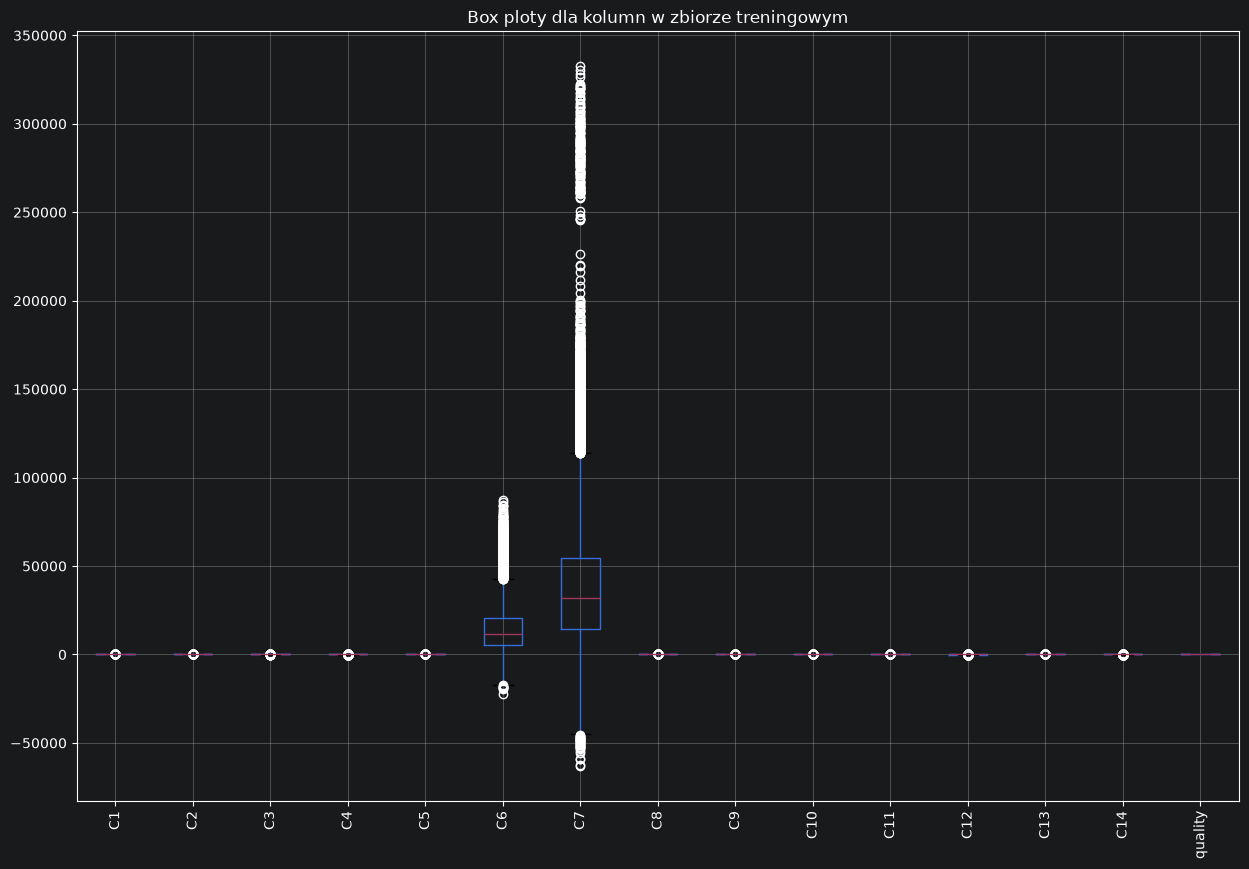

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Wyświetlanie box plotów dla wszystkich kolumn numerycznych w df_train
plt.figure(figsize=(15, 10))
df_train.boxplot()
plt.title('Box ploty dla kolumn w zbiorze treningowym')
plt.xticks(rotation=90)
plt.show()

In [13]:
# Implementacja cappingu przy użyciu metody IQR dla kolumn 'C7' i 'C6'

columns_to_cap = ['C7', 'C6']

for col in columns_to_cap:
    # Obliczanie kwartyli i IQR dla kolumny w zbiorze treningowym
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definiowanie granic dla wartości odstających
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Ograniczenie wartości odstających w zbiorze treningowym
    df_train[col] = df_train[col].clip(lower=lower_bound, upper=upper_bound)

    # Ograniczenie wartości odstających w zbiorze testowym przy użyciu granic ze zbioru treningowego
    df_test[col] = df_test[col].clip(lower=lower_bound, upper=upper_bound)


print(f"Wartości odstające w kolumnach {columns_to_cap} zostały ograniczone.")

Wartości odstające w kolumnach ['C7', 'C6'] zostały ograniczone.


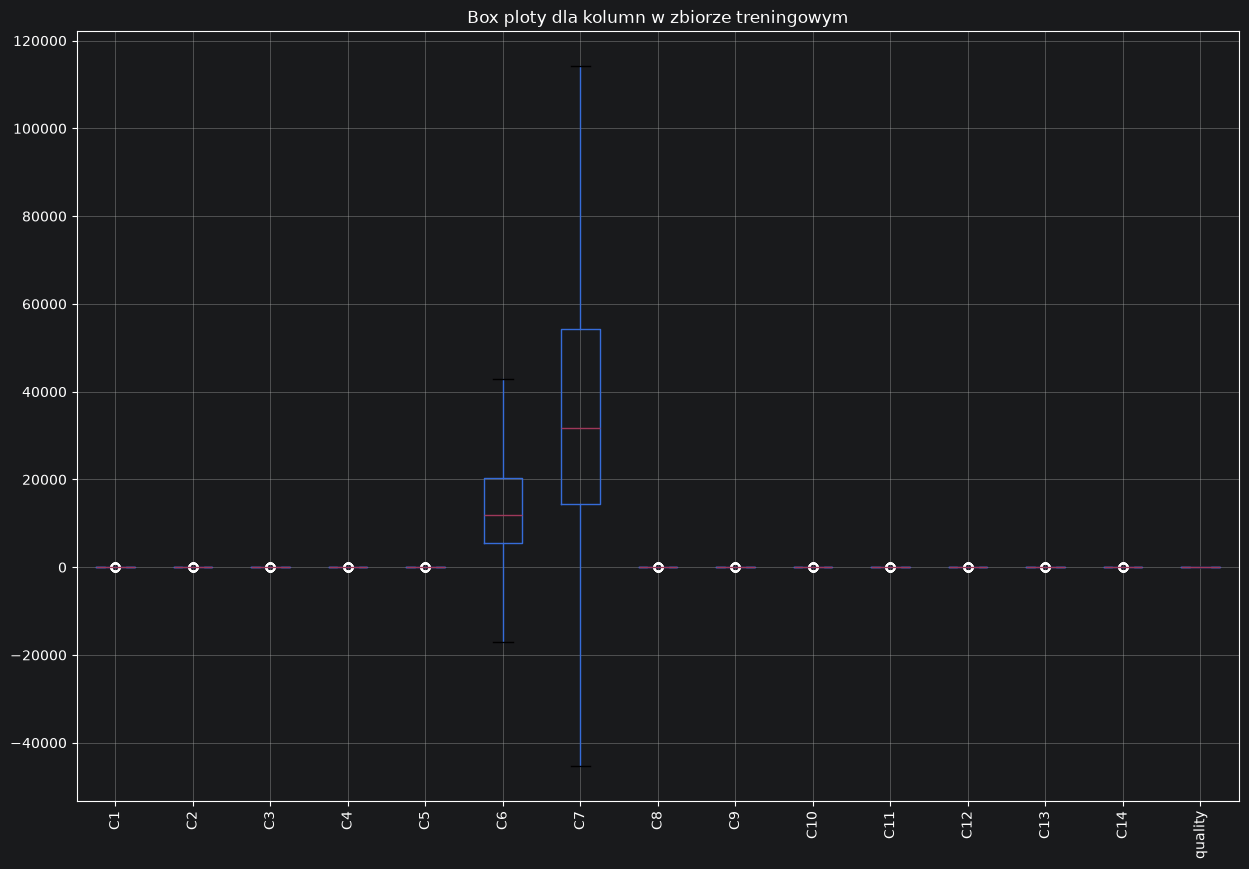

In [14]:
# Wyświetlanie box plotów dla wszystkich kolumn numerycznych w df_train
plt.figure(figsize=(15, 10))
df_train.boxplot()
plt.title('Box ploty dla kolumn w zbiorze treningowym')
plt.xticks(rotation=90)
plt.show()

Macierz korelacji:
               C1        C2        C3        C4        C6        C7        C8  \
C1       1.000000 -0.238014  0.548806  0.066901 -0.061327 -0.081485  0.506219   
C2      -0.238014  1.000000 -0.491260  0.011432 -0.127658 -0.084403  0.016308   
C3       0.548806 -0.491260  1.000000  0.080931  0.007258  0.033380  0.281215   
C4       0.066901  0.011432  0.080931  1.000000 -0.048859  0.040127  0.226721   
C6      -0.061327 -0.127658  0.007258 -0.048859  1.000000  0.509943 -0.084574   
C7      -0.081485 -0.084403  0.033380  0.040127  0.509943  1.000000 -0.028487   
C8       0.506219  0.016308  0.281215  0.226721 -0.084574 -0.028487  1.000000   
C9      -0.519397  0.334784 -0.501970 -0.035585  0.012955 -0.016207 -0.264919   
C10      0.134715 -0.345346  0.313684 -0.032094  0.125014  0.110007  0.029513   
C11     -0.142855 -0.149707  0.052198  0.103739  0.009966 -0.044963 -0.446487   
C12     -0.088319 -0.043866 -0.066517 -0.012769  0.033266  0.025222 -0.132756   
C13     -

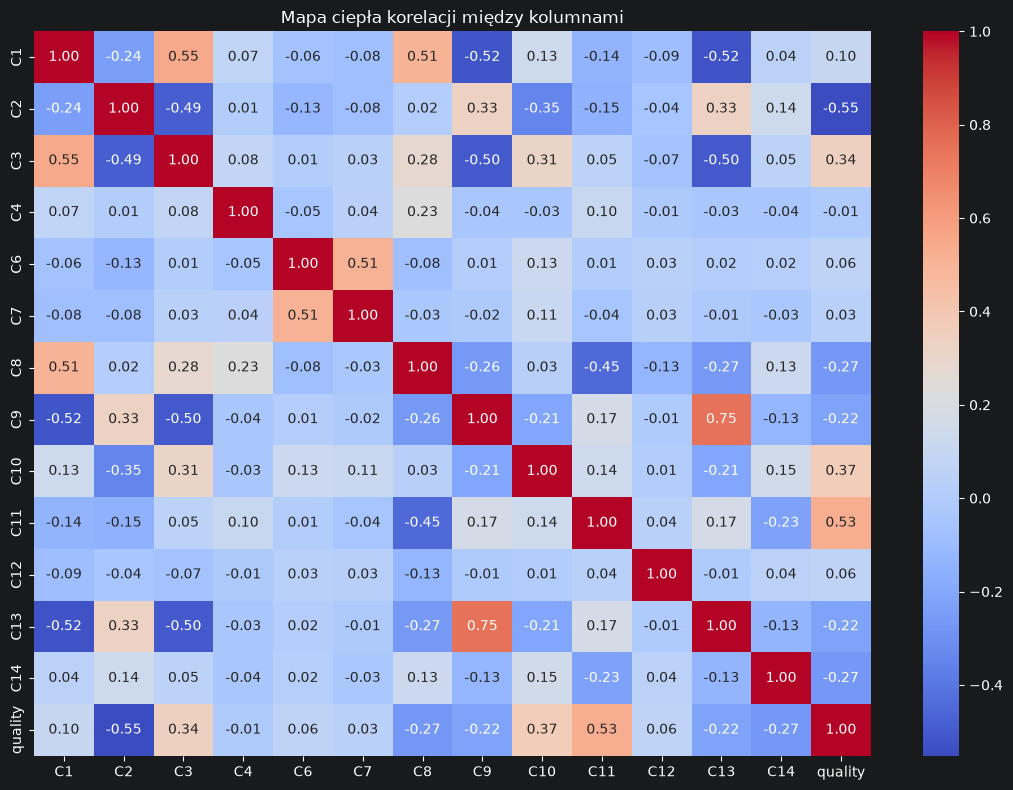

In [15]:
df_train_n = df_train.drop(columns=['C5'])
df_test_n = df_test.drop(columns=['C5'])
#df_train_n = df_train
#df_test_n = df_test

macierz_korelacji = df_train_n.corr(numeric_only=True)

# Wyświetlamy wynikową tabelę
print("Macierz korelacji:")
print(macierz_korelacji)

# Ustawiamy rozmiar wykresu, aby był bardziej czytelny
plt.figure(figsize=(11, 8))

# Tworzymy mapę ciepła
# annot=True - wyświetla wartości w komórkach
# cmap='coolwarm' - używa kolorów od niebieskiego (korelacja ujemna) do czerwonego (dodatnia)
sns.heatmap(macierz_korelacji, annot=True, cmap='coolwarm', fmt=".2f")

# Dodajemy tytuł
plt.title('Mapa ciepła korelacji między kolumnami')

# Wyświetlamy wykres
plt.tight_layout()

In [16]:
X_train = df_train_n.drop('quality', axis=1)
y_train = df_train_n['quality']

X_test = df_test_n.drop('quality', axis=1)
y_test = df_test_n['quality']

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print(accuracy_score(y_test, y_pred))

0.8717948717948718


Wykryte nazwy klas (jako liczby): [3 4 5 6 7 8]


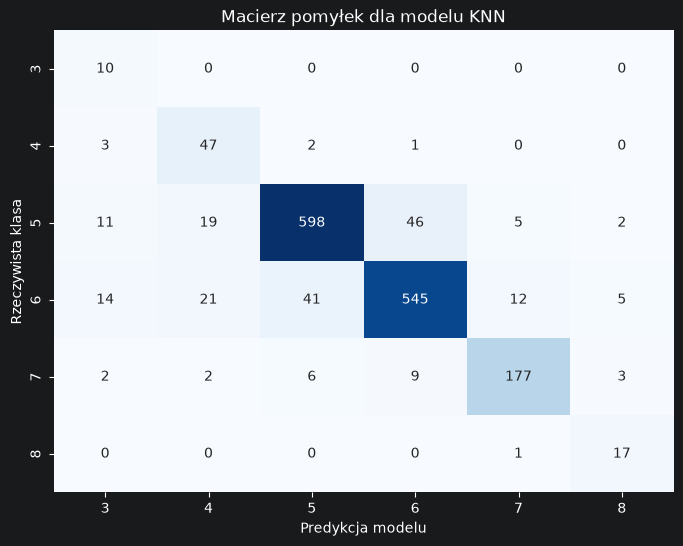


Raport klasyfikacji:
              precision    recall  f1-score   support

           3       0.25      1.00      0.40        10
           4       0.53      0.89      0.66        53
           5       0.92      0.88      0.90       681
           6       0.91      0.85      0.88       638
           7       0.91      0.89      0.90       199
           8       0.63      0.94      0.76        18

    accuracy                           0.87      1599
   macro avg       0.69      0.91      0.75      1599
weighted avg       0.89      0.87      0.88      1599



In [17]:
# Pobieramy klasy (to są liczby, np. [3, 4, 5, 6, 7, 8])
class_names_int = knn.classes_
print(f"Wykryte nazwy klas (jako liczby): {class_names_int}")

# --- ROZWIĄZANIE ---
# Konwertujemy liczby na stringi (tekst) na potrzeby etykiet
# Funkcje raportujące (jak classification_report) oczekują stringów
class_names_str = [str(c) for c in class_names_int]
# alternatywnie: class_names_str = list(map(str, class_names_int))


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Obliczamy macierz pomyłek
cm = confusion_matrix(y_test, y_pred)

# Tworzymy wizualizację macierzy pomyłek
plt.figure(figsize=(8, 6))
# Używamy skonwertowanych etykiet (stringów) dla spójności
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_str, yticklabels=class_names_str)
plt.xlabel("Predykcja modelu")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek dla modelu KNN")
plt.show()

# Wyświetlamy szczegółowy raport klasyfikacji
print("\nRaport klasyfikacji:")
# Używamy listy stringów - teraz zadziała poprawnie
print(classification_report(y_test, y_pred, target_names=class_names_str))

In [18]:
print("\nLiczba wierszy dla poszczególnych klas w zbiorze testowym:")
print(y_test.value_counts())


Liczba wierszy dla poszczególnych klas w zbiorze testowym:
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


1. Opis działania

    Dane są numeryczne. Zbiór df_train jest duży ma 20 mln wierszy.
    
    Statystyki opisowe ujawniają duże rozpiętości wartości i potencjalne wartości odstające (outliery) w kolumnach C6, C7 (duże wartości maksymalne i odchylenia standardowe).

    Po pierwsze usunąłem duplkaty co znacząco zmniejszyło rozmiar zbioru do ~10 mln wierszy. Jest to kluczowy krok optymalizacyjny. Zduplikowane wiersze mogą sztucznie zawyżać liczebność pewnych obserwacji oraz modele mogą "zbyt dobrze" nauczyć się wzorców obecnych w zduplikowanych danych, co prowadzi do słabej generalizacji na nowych, niewidzianych wcześniej danych. Przetwarzanie zbędnych, powtarzających się danych zwiększa czas trenowania modeli i zużycie pamięci bez dodawania wartości informacyjnej.

    Następnnym krokiem było sprawdzenie data leakage. Zaimplementowałem mechanizm sprawdzający, czy wiersze ze zbioru testowego występują w zbiorze treningowym. Stworzono unikalny "klucz" dla każdego wiersza, łącząc wartości wszystkich kolumn jako tekst. Znaleziono 1 wspólny wiersz. Chociaż jego wpływ na wynik przy tak dużym zbiorze danych jest znikomy, w praktyce należałoby go usunąć ze zbioru treningowego.

    Kolejnie sprawdziłem braki w danych ale wynik pokazał brak brakujących danych

    Następnie wygenerowane boxploty potwierdziły obecność znaczących wartości odstających, szczególnie w kolumnach C6 i C7. dlatego zastosowano metode clappingu opartą na rozstępie międzykwartylowym


      *   Obliczono pierwszy (Q1) i trzeci (Q3) kwartyl oraz IQR (IQR = Q3 - Q1) dla tych kolumn na zbiorze treningowym
      *   Zdefiniowano granice: dolną (Q1 - 1.5 * IQR) i górną (Q3 + 1.5 * IQR)
      *   Wartości w kolumnach C6 i C7, które wychodziły poza te granice, zostały zastąpione odpowiednimi wartościami granicznymi, Co ważne, te same granice, obliczone na zbiorze treningowym, zastosowano do ograniczenia wartości w zbiorze testowym, aby uniknąć wycieku informacji ze zbioru testowego.
      *   Wygenerowano ponownie wykresy pudełkowe, które pokazały, że zakres wartości dla C6 i C7 został znacznie ograniczony


    Clipping był ważny w tym przypadku, ponieważ algorytm KNN opiera swoje działanie na odległościach między punktami danych. Wykryte w kolumnach C6 i C7 ekstremalne wartości odstające mogłyby nieproporcjonalnie zaburzyć te obliczenia, zniekształcając sposób, w jaki model postrzega podobieństwo między próbkami wina. Ograniczenie tych wartości (clipping) zneutralizowało ich nadmierny wpływ, co ustabilizowało model i przyczyniło się do uzyskania lepszej dokładności klasyfikacji.


    Zastosowałem MinMaxScaler do przeskalowania wartości cech w X_train i X_test do zakresu [0, 1] ponieważ algorytmu KNN, który jest bardzo wrażliwy na odległości między punktami. MinMaxScaler przeskalował wszystkie cechy do jednolitego zakresu, co zapewniło, że żadna cecha nie zdominuje obliczeń odległości tylko ze względu na swoją skalę Ponieważ wcześniej zająłem się problemem ekstremalnych outlierów za pomocą clippingu co jest główną wadą MinMaxScaler, bo jest na nie wrażliwy, jego zastosowanie stało się bezpieczniejsze i pozwoliło skutecznie ujednolicić zakresy wszystkich cech dla KNN

2. Wnioski

    Kroki takie jak usunięcie duplikatów, ograniczenie wartości odstających w C6 i C7 oraz skalowanie MinMax były niezbędne do przygotowania dużego zbioru danych i uzyskania dobrego wyniku przez algorytm KNN.

    Klasy jakości wina nie są równoliczne. Klasy '5' i '6' są dominujące, podczas gdy klasy '3' i '8' są bardzo nieliczne. Model ma najwyższą precyzję, pełność i F1-score dla klas '5' i '6', Dla klas mniejszościowych  metryki są znacznie niższe, mimo wysokiej pełności. Model dobrze znajduje próbki tych klas, ale często mylnie klasyfikuje inne próbki jako należące do tych rzadkich klas. Wynika to z faktu, że w sąsiedztwie punktu z rzadkiej klasy częściej znajdują się punkty z klas dominujących